In [10]:
#import needed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
print("works")


works


In [40]:
#read my csv file & clean data
df = pd.read_csv("Invistico_Airline.csv", encoding="utf-8-sig")
df.head()


,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Female,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Male,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Female,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Female,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Female,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,...,4,2,2,0,2,4,2,5,0,0.0


In [41]:
df.columns

Index(['satisfaction', 'Gender', 'Customer Type', 'Age', 'Type of Travel',
       'Class', 'Flight Distance', 'Seat comfort',
       'Departure/Arrival time convenient', 'Food and drink', 'Gate location',
       'Inflight wifi service', 'Inflight entertainment', 'Online support',
       'Ease of Online booking', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding',
       'Departure Delay in Minutes', 'Arrival Delay in Minutes'],
      dtype='str')

In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  str    
 1   Gender                             129880 non-null  str    
 2   Customer Type                      129880 non-null  str    
 3   Age                                129880 non-null  int64  
 4   Type of Travel                     129880 non-null  str    
 5   Class                              129880 non-null  str    
 6   Flight Distance                    129880 non-null  int64  
 7   Seat comfort                       129880 non-null  int64  
 8   Departure/Arrival time convenient  129880 non-null  int64  
 9   Food and drink                     129880 non-null  int64  
 10  Gate location                      129880 non-null  int64  
 11  Inflight wifi service              129880 non-null

In [43]:
df.describe()

,Age,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000
mean,39.427957,1981.409055,2.838597,2.990645,2.851994,2.990422,3.249130,3.383477,3.519703,3.472105,3.465075,3.485902,3.695673,3.340807,3.705759,3.352587,14.713713,15.091129
std,15.119360,1027.115606,1.392983,1.527224,1.443729,1.305970,1.318818,1.346059,1.306511,1.305560,1.270836,1.292226,1.156483,1.260582,1.151774,1.298715,38.071126,38.465650
min,7.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,1359.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,40.000000,1925.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,0.000000,0.000000
75%,51.000000,2544.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,4.000000,5.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,85.000000,6951.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [44]:
df.isnull().sum()

satisfaction                           0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Seat comfort                           0
Departure/Arrival time convenient      0
Food and drink                         0
Gate location                          0
Inflight wifi service                  0
Inflight entertainment                 0
Online support                         0
Ease of Online booking                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Online boarding                        0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
dtype: int64

In [35]:
#missing values in "Arrival Delay in Minutes " column is only around 3% of total
df["Arrival Delay in Minutes"].isnull().sum()

np.int64(393)

In [45]:
#step1:droping them seems like the best option, since it would't affect the data
#step2:Quick check that there are no missing values
df = df.dropna(subset = ["Arrival Delay in Minutes"])
print("number of missing values after dropping: ", df["Arrival Delay in Minutes"].isnull().sum())

number of missing values after dropping:  0


In [46]:
#Quick check if there are duplicates that need inspection
df.duplicated().sum()

np.int64(0)

## visual 1 - Overall Customer Satisfaction Distribution:

This visualization shows the total satisfied vs dissatisfied customers.

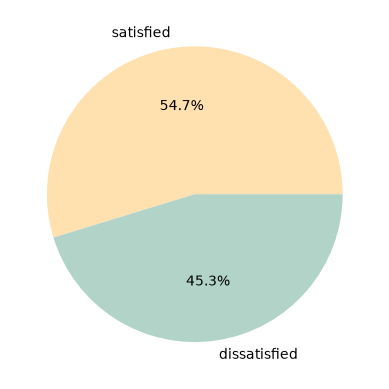

In [121]:
#Visualizing the total satisfaction in general using pie chart
#what is the percentage of satisfied vs dissatisfied passengers ?
sat = (
    df["satisfaction"].value_counts(normalize=True)*100

)

plt.pie(
    sat,
    labels=sat.index,
    autopct="%1.1f%%",
    colors=["#ffe0af","#b1d3c8"]
)
plt.show()

### Insight:
The dataset contains a larger proportion of satisfied passengers compared to dissatisfied passengers, indicating generally positive customer experiences among airline passengers.

## visual 2 - Which Service Cotributes the Most to Customer Satisfaction?

This visualization shows the most cotributing services to customer satisfaction.

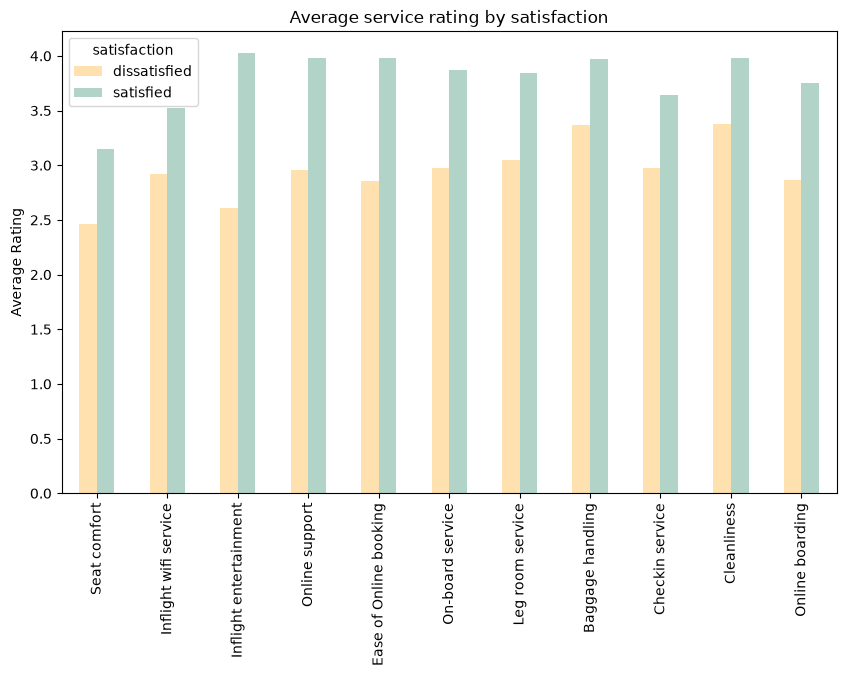

In [109]:
#step1:calculate the mean of satisfied/dissatisfied of each service
ser_col=['Seat comfort', 'Inflight wifi service', 'Inflight entertainment', 'Online support', 
         'Ease of Online booking', 'On-board service', 'Leg room service', 'Baggage handling', 
         'Checkin service', 'Cleanliness', 'Online boarding']

means = (df.groupby("satisfaction")[ser_col].mean())



#step2:visualizing the results
means.T.plot(kind = "bar", figsize=(10,6), color=[ "#ffe0af", "#b1d3c8"])
plt.ylabel("Average Rating")
plt.title("Average service rating by satisfaction")
plt.show()

### Insight:
The Inflight Entertainment service appears to be the most contributing service to customer satisfaction, whereas seat comport appears to have the least contribution in customer satisfaction.

## visual 3 - Does the class type Business/Eco affect the rating ?

This visualization shows the effect of class type  on customer satisfaction rate.

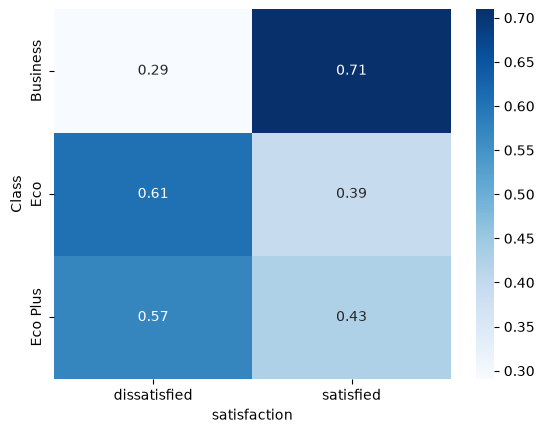

In [70]:
#create table for the values
#'normalize' converts counts into percentages
cross = pd.crosstab(df["Class"], df["satisfaction"], normalize="index")

#use the table for the visualization
sns.heatmap(cross, annot=True, cmap="Blues")
plt.show()

### Insight:
The class type has a big affect on the customer satisfaction rate. The satisfaction reaches the highest rate when the class is "Business", which clearly shows the affect of class type on customer satisfaction.

## visual 4, 5 - Does the Arrival/Departure Delay affect the rating ?

These visualizations show the effect of Arrival/Departure Delay on customer satisfaction rate.

In [ ]:
#Feature Engineering
#Defined a new column to better represent the values of Arrival/Departue delay from minutes --> category
df["Arrival_status"]= pd.cut(df["Arrival Delay in Minutes"], bins = [-1, 0, 15, 60, float("inf")], 
                             labels = [ "On Time", "Short Delay", "Moderate Delay", "Long Delay"])

df["Departure_status"]= pd.cut(df["Departure Delay in Minutes"], bins = [-1, 0, 15, 60, float("inf")], 
                             labels = [ "On Time", "Short Delay", "Moderate Delay", "Long Delay"])

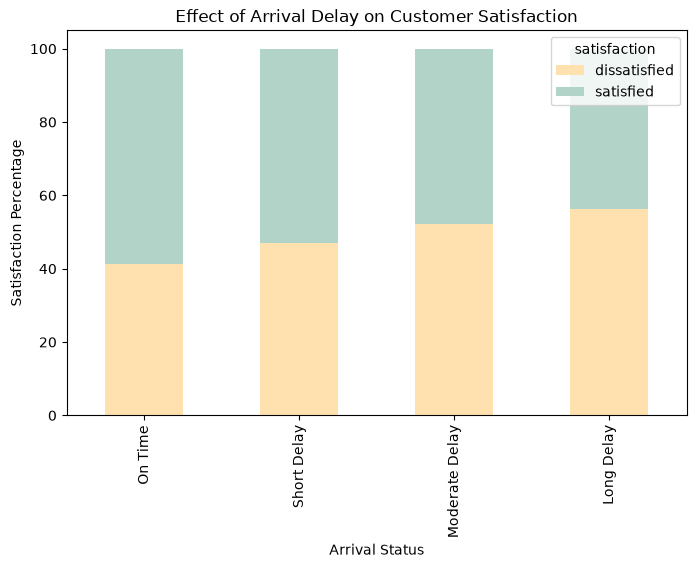

In [108]:
#the effect of arrival delay on passenger satisfaction
cross = (
pd.crosstab(
df["Arrival_status"],
df["satisfaction"],
normalize="index"
)*100
)

cross.plot(
kind="bar",
stacked=True,
figsize=(8,5),
color=[ "#ffe0af", "#b1d3c8"]
)

plt.ylabel("Satisfaction Percentage")
plt.xlabel("Arrival Status")
plt.title(
"Effect of Arrival Delay on Customer Satisfaction"
)

plt.show()

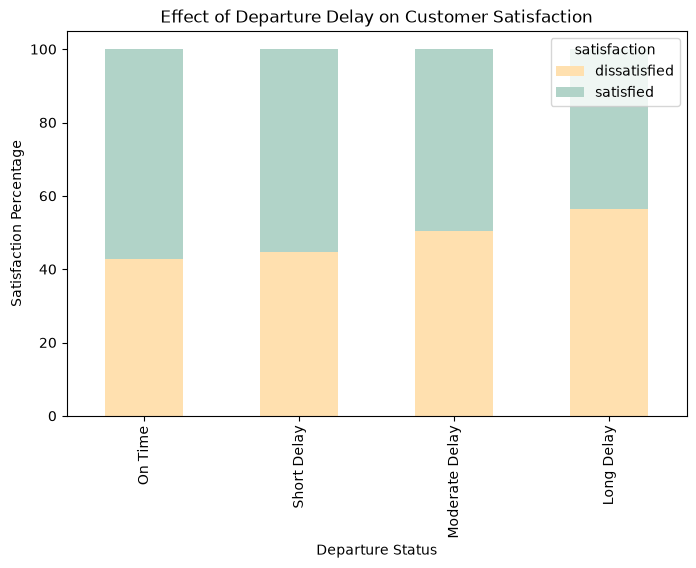

In [107]:
##the effect of departure delay on passenger satisfaction

cross = (pd.crosstab(df["Departure_status"], df["satisfaction"], normalize = "index")*100)

cross.plot(kind="bar", stacked="True", figsize=(8,5), color=["#ffe0af", "#b1d3c8"])

plt.ylabel("Satisfaction Percentage")
plt.xlabel("Departure Status")
plt.title("Effect of Departure Delay on Customer Satisfaction")
plt.show()

### Insight:
Both Arrival and Departure Delays affects the satisfaction rate negatively. The more Delay time, the more dissatisfied ratings the flight get.

## visual 6 - Does the Customer Type Affect the Rating ?

This visualization shows the effect of customer type on the satisfaction rate.

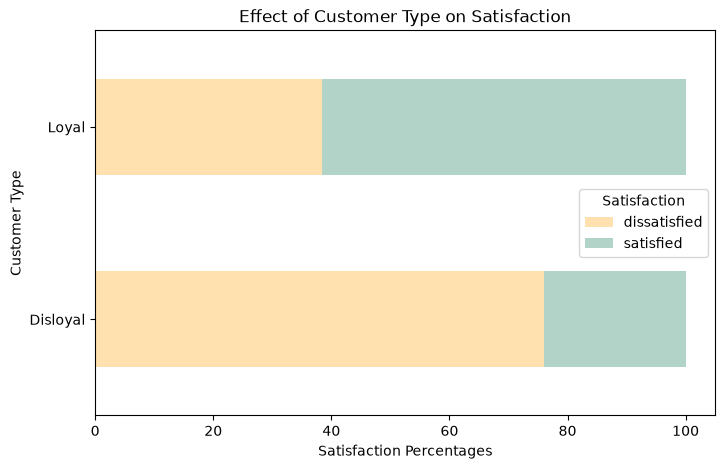

In [102]:
#the effect of customer type on the satisfaction
#Encoding the customer type as 1="Loyal" and 0="disloyal" then visualizing 
#step 1: encoding
df["customer_encoded"] = (df["Customer Type"].map({"disloyal Customer":0, "Loyal Customer":1}) )
#creating percentages of satisfaction within each customer type
cross = (
    pd.crosstab(
        df["customer_encoded"], df["satisfaction"], normalize="index"
    )*100
)

#step 2: visualize
cross.plot(
    kind="barh",
    stacked=True,
    figsize=(8, 5),
    color=[ "#ffe0af", "#b1d3c8"]
)

plt.yticks(
    [0,1],
    ["Disloyal", "Loyal"]
)
plt.ylabel("Customer Type")
plt.xlabel("Satisfaction Percentages")
plt.title("Effect of Customer Type on Satisfaction")
plt.legend(title="Satisfaction")
plt.show()

### Insight:
This visualization shows that loyal customers tend to report higher satisfaction rates, whereas disloyal customers appear more likely to be dissatisfied.

## visual 7 - Does the Flight Distance Affect the Rating ?

This visualization shows the effect of flight distance on the satisfaction rate.

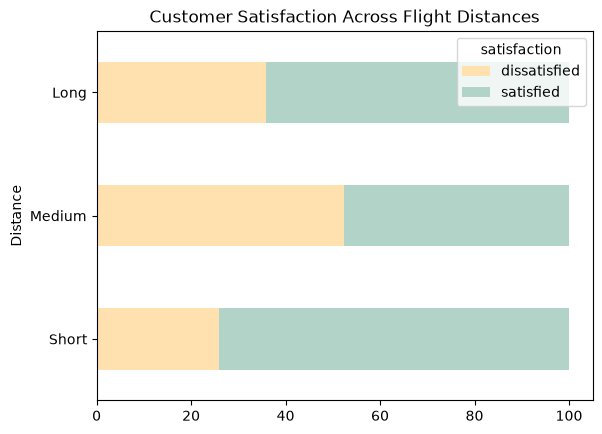

In [116]:
#Creating distance categories to better visualize the affect of flight distance on satisfaction
df["Distance Group"] = pd.cut(
    df["Flight Distance"],
    bins=[0,1000,3000,6000],
    labels=["Short", "Medium", "Long"]
)

cross=(
    pd.crosstab(
        df["Distance Group"],
        df["satisfaction"],
        normalize="index"
    )*100
)

cross.plot(
    kind="barh",
    stacked=True,
    color=["#ffe0af","#b1d3c8"]

)
plt.title("Customer Satisfaction Across Flight Distances")
plt.ylabel("Distance")
plt.show()



### Insight:
This visualization shows that short-distance flights have the highest satisfaction rates, whereas medium- and long-distance flights appear to have lower satisfaction levels.

## visual 8 - Which Age Group Shows the Highest Dissatisfaction?

This visualization explores whether customer dissatisfaction is concentrated within specific age groups.

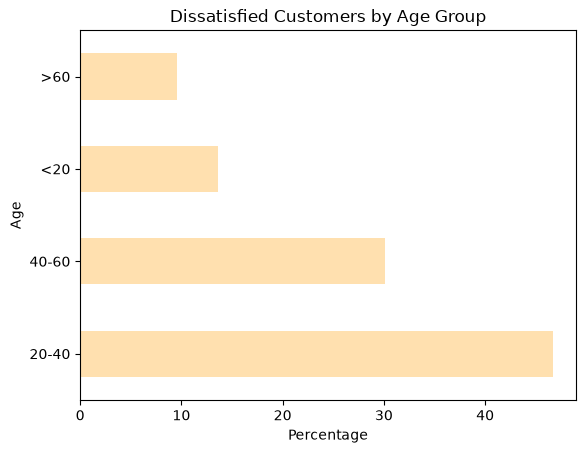

In [129]:
#Grouping passengers by age 
df["Age Group"]= pd.cut(df["Age"], bins = [0,20,40,60,100], labels=["<20", "20-40", "40-60", ">60"])

#visualizing the dissatisfied passengers by age 
age_profile = (
    df[
        df["satisfaction"]=="dissatisfied"]
        ["Age Group"].value_counts(
            normalize=True

        )*100
    
)
age_profile.plot(
kind="barh",
color="#ffe0af"
)

plt.xlabel("Percentage")

plt.title(
"Dissatisfied Customers by Age Group"
)
plt.ylabel("Age")
plt.show()


### Insight:
This visualization shows that dissatisfaction was more concentrated among certain age groups (20-40), indicating that passenger experience may vary across age categories.